<a href="https://colab.research.google.com/github/Ameena1BM23CS27/6thSem-ML-Lab/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix


In [2]:
iris = pd.read_csv("iris (1) (1).csv")

In [3]:
X = iris.iloc[:, :-1]
y = iris.iloc[:, -1]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("=== Linear Kernel ===")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))


=== Linear Kernel ===
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [6]:
rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

y_pred_rbf = rbf_model.predict(X_test)

print("\n=== RBF Kernel ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))


=== RBF Kernel ===
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [7]:
#DRUG DATASET

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, label_binarize
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier


In [9]:
drug = pd.read_csv("drug.csv")


In [10]:
le = LabelEncoder()
for col in drug.columns:
    if drug[col].dtype == 'object':
        drug[col] = le.fit_transform(drug[col])

# Features and target
X = drug.iloc[:, :-1]
y = drug.iloc[:, -1]

In [11]:
y_bin = label_binarize(y, classes=list(set(y)))
n_classes = y_bin.shape[1]


In [12]:
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    X, y, y_bin, test_size=0.2, random_state=42
)

In [13]:
model = OneVsRestClassifier(SVC(kernel='linear', probability=True))
model.fit(X_train, y_train)


OneVsRestClassifier(estimator=SVC(kernel='linear', probability=True))

In [14]:
y_pred = model.predict(X_test)

print("=== Drug Dataset SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

=== Drug Dataset SVM ===
Accuracy: 0.875
Confusion Matrix:
 [[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 1  0  0  3  1]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]


In [15]:
y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


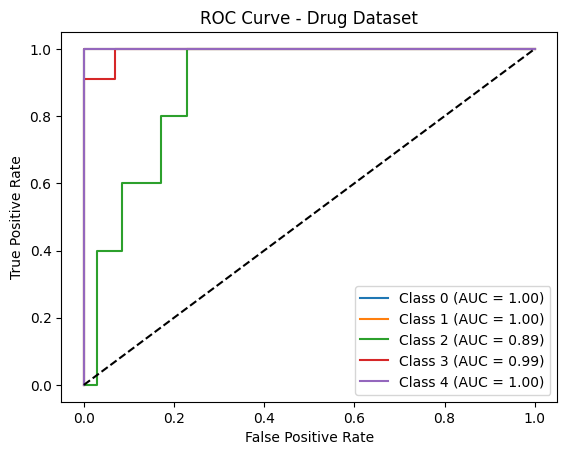

In [16]:
plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Drug Dataset")
plt.legend()
plt.show()

In [17]:
for i in range(n_classes):
    print(f"AUC for class {i}:", roc_auc[i])

AUC for class 0: 1.0
AUC for class 1: 1.0
AUC for class 2: 0.8914285714285715
AUC for class 3: 0.9937304075235109
AUC for class 4: 1.0
